## 1.- Imports y Configuracion.

In [43]:
import sys
import os

# Obtener ruta absoluta del proyecto
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# agregar src al path
sys.path.append(os.path.join(project_root, "src"))


In [44]:
# importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data

sns.set(style="whitegrid")

In [46]:
# Cargar datos

df = load_data("../data/earthquakes_1900_2026.csv")
df

✅ Dataset cargado correctamente
Filas : 1054683, Columnas : 23


,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
0,cent19000105190000000,1900-01-05 19:00:00+00:00,1900,1,5,19,-3.000000,102.000000,NaN,7.000000,...,0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T00:16:56.005Z,reviewed
1,cent19000111090700000,1900-01-11 09:07:00+00:00,1900,1,11,9,-5.000000,148.000000,NaN,7.000000,...,0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T22:55:15.621Z,reviewed
2,cent19000120063300000,1900-01-20 06:33:00+00:00,1900,1,20,6,20.000000,-105.000000,NaN,7.300000,...,0,Great (7-8),NaN,NaN,NaN,NaN,NaN,cent,2025-04-19T23:36:34.400Z,reviewed
3,cent19000131192200000,1900-01-31 19:22:00+00:00,1900,1,31,19,48.000000,146.000000,450.000,7.500000,...,0,Great (7-8),Deep (300-700km),NaN,NaN,NaN,NaN,cent,2025-04-26T21:47:57.256Z,reviewed
4,ushis388,1900-04-09 14:00:00+00:00,1900,4,99,14,41.370000,-81.850000,0.000,3.400000,...,0,Light (3-4),Shallow (0-70km),NaN,NaN,NaN,NaN,ushis,2023-12-03T23:47:09.672Z,automatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054678,us6000smnq,2026-04-04 21:23:59.497000+00:00,2026,4,94,21,24.051800,121.617500,23.376,4.400000,...,0,Moderate (4-5),Shallow (0-70km),57.0,66.0,0.12300,0.95,us,2026-04-05T01:59:05.040Z,reviewed
1054679,us6000smp0,2026-04-04 22:04:38.745000+00:00,2026,4,94,22,39.922200,-107.134400,5.000,2.500000,...,0,Minor (2.5-3),Shallow (0-70km),20.0,83.0,0.45400,1.04,us,2026-04-05T00:54:17.040Z,reviewed
1054680,us6000smp9,2026-04-04 22:31:20.621000+00:00,2026,4,94,22,-31.520300,-177.976600,30.861,5.000000,...,0,Moderate (4-5),Shallow (0-70km),26.0,151.0,2.26800,1.25,us,2026-04-04T22:50:25.040Z,reviewed
1054681,us6000smpb,2026-04-04 22:37:50.166000+00:00,2026,4,94,22,1.447300,126.614600,35.000,4.500000,...,0,Moderate (4-5),Shallow (0-70km),39.0,99.0,7.10900,1.11,us,2026-04-05T01:46:17.040Z,reviewed


## 2.- Inspeccion Inicial

In [47]:
df.shape

(1054683, 23)

In [7]:
print(df.columns)

Index(['id', 'time', 'year', 'month', 'day_of_year', 'hour', 'latitude',
       'longitude', 'depth', 'mag', 'magType', 'place', 'type', 'tsunami',
       'mag_category', 'depth_category', 'nst', 'gap', 'dmin', 'rms', 'net',
       'updated', 'status'],
      dtype='str')


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054683 entries, 0 to 1054682
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1054683 non-null  str    
 1   time            1054683 non-null  str    
 2   year            1054683 non-null  int64  
 3   month           1054683 non-null  int64  
 4   day_of_year     1054683 non-null  int64  
 5   hour            1054683 non-null  int64  
 6   latitude        1054683 non-null  float64
 7   longitude       1054683 non-null  float64
 8   depth           1053791 non-null  float64
 9   mag             1054683 non-null  float64
 10  magType         1054599 non-null  str    
 11  place           1054683 non-null  str    
 12  type            1054683 non-null  str    
 13  tsunami         1054683 non-null  int64  
 14  mag_category    1054683 non-null  str    
 15  depth_category  1053785 non-null  str    
 16  nst             558968 non-null   float64
 17  

In [49]:
df.describe()

,year,month,day_of_year,hour,latitude,longitude,depth,mag,tsunami,nst,gap,dmin,rms
count,1.054683e+06,1.054683e+06,1.054683e+06,1.054683e+06,1.054683e+06,1.054683e+06,1.053791e+06,1.054683e+06,1054683.0,558968.000000,673635.000000,380975.000000,878131.000000
mean,2.003353e+03,6.471018e+00,1.814476e+02,1.155436e+01,2.016444e+01,-2.114013e+01,5.329371e+01,3.844124e+00,0.0,33.927071,139.192121,2.136737,0.695564
std,1.683438e+01,3.418864e+00,1.044286e+02,6.969818e+00,2.940922e+01,1.205227e+02,9.954571e+01,9.303126e-01,0.0,51.022166,79.236030,3.921382,0.470158
min,1.900000e+03,1.000000e+00,1.000000e+00,0.000000e+00,-8.449320e+01,-1.799997e+02,-4.000000e+00,7.000000e-01,0.0,0.000000,0.000000,0.000000,-1.000000
25%,1.994000e+03,4.000000e+00,9.200000e+01,5.000000e+00,-3.247350e+00,-1.215118e+02,1.000000e+01,2.940000e+00,0.0,10.000000,75.000000,0.207000,0.360000
50%,2.006000e+03,7.000000e+00,1.820000e+02,1.200000e+01,2.943500e+01,-6.684680e+01,1.978000e+01,4.000000e+00,0.0,19.000000,123.000000,0.877900,0.710000
75%,2.017000e+03,9.000000e+00,2.710000e+02,1.800000e+01,4.057282e+01,1.190265e+02,4.580000e+01,4.500000e+00,0.0,38.000000,194.000000,2.446000,1.000000
max,2.026000e+03,1.200000e+01,3.660000e+02,2.300000e+01,8.738600e+01,1.800000e+02,7.358000e+02,9.500000e+00,0.0,934.000000,360.000000,127.420000,104.330000


## 3.- Calidad de Datos

In [50]:
# Valores Nulos

df.isnull().sum()


id                     0
time                   0
year                   0
month                  0
day_of_year            0
hour                   0
latitude               0
longitude              0
depth                892
mag                    0
magType               84
place                  0
type                   0
tsunami                0
mag_category           0
depth_category       898
nst               495715
gap               381048
dmin              673708
rms               176552
net                    0
updated                0
status                 0
dtype: int64

In [51]:
# Eliminacion de Valores Duplicados

df = df.drop_duplicates()

## 4.- Analisis Univariado.

#### Analizar variables clave como magnitud, profundidad, etc.

## 4.1.- Histograma.

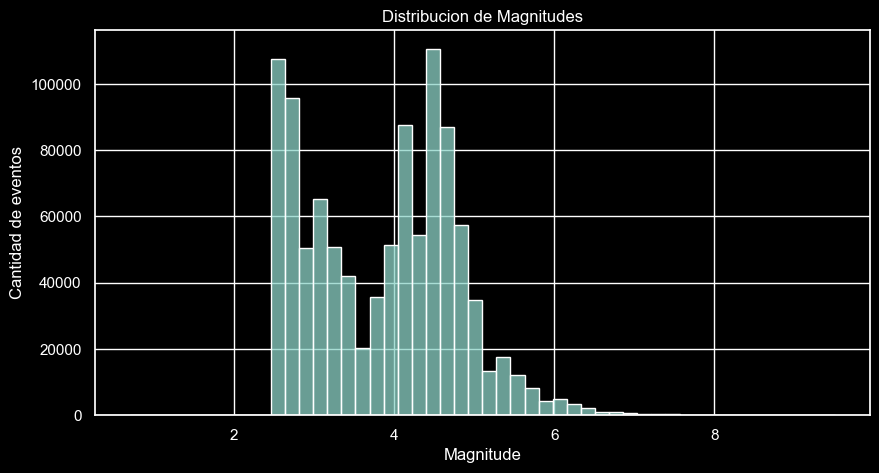

In [121]:
plt.figure(figsize=(10,5))
sns.histplot(df['mag'], bins=50)
plt.title('Distribucion de Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Cantidad de eventos')
plt.show()

## 4.2.- Boxplot.

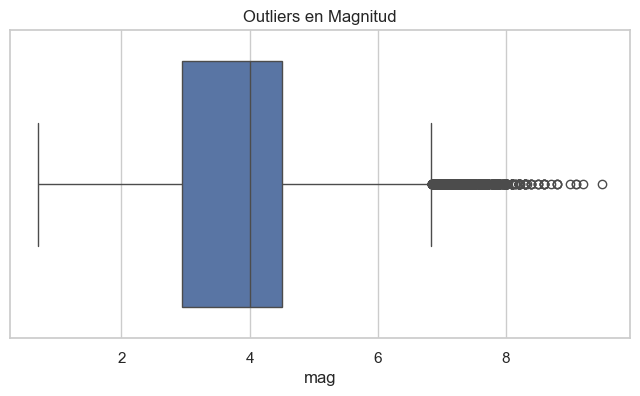

In [53]:
plt.figure(figsize=(8,4))
sns.boxplot(x = df['mag'])
plt.title('Outliers en Magnitud')
plt.show()

## 5.- Analisis Temporal.

In [75]:
df['year'].describe()

count    1.054683e+06
mean     2.003353e+03
std      1.683438e+01
min      1.900000e+03
25%      1.994000e+03
50%      2.006000e+03
75%      2.017000e+03
max      2.026000e+03
Name: year, dtype: float64

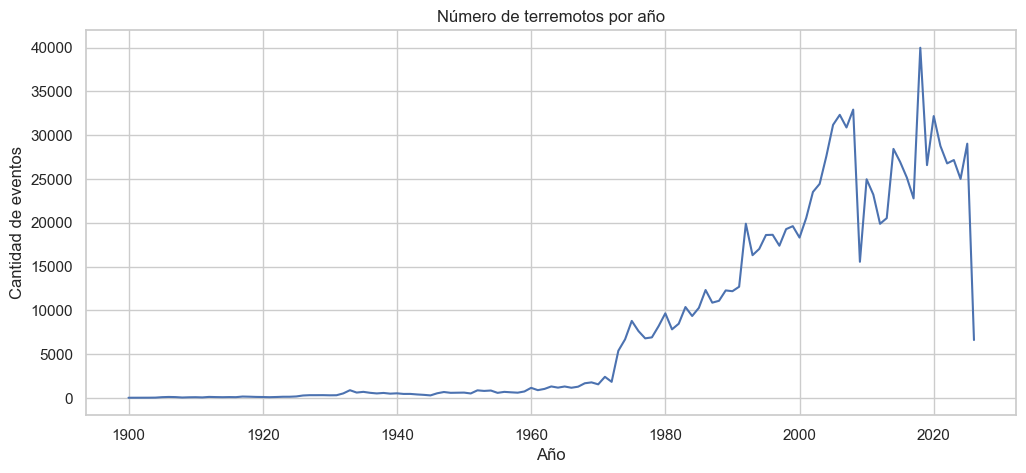

In [76]:
# Grafica de Terremotos por año

earthquakes_per_year = df.groupby("year").size().sort_index()

plt.figure(figsize=(12,5))
earthquakes_per_year.plot()
plt.title("Número de terremotos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de eventos")
plt.show()

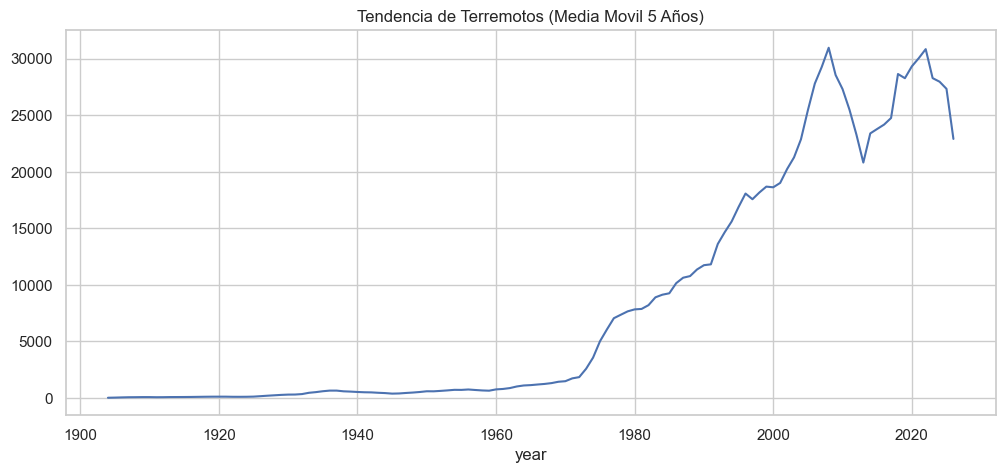

In [77]:
# Grafica de la Tendencia de Terremotos a cada 5 Años

earthquakes_per_year.rolling(5).mean().plot(figsize=(12,5))
plt.title('Tendencia de Terremotos (Media Movil 5 Años)')
plt.show()

In [79]:
# Años con mas Terremotos

años_mas_terremotos = earthquakes_per_year.sort_values(ascending = False)
años_mas_terremotos.head(10)

year
2018    39980
2008    32917
2006    32321
2020    32180
2005    31175
2007    30877
2025    29025
2021    28763
2014    28431
2004    27600
dtype: int64

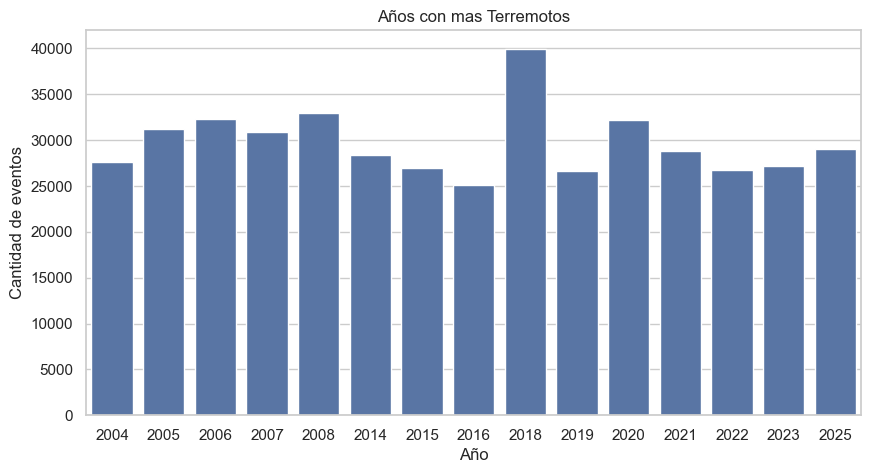

In [80]:
# Grafica con los Años con mas Terremotos

plt.figure(figsize=(10,5))
sns.barplot(años_mas_terremotos.head(15))
plt.xlabel('Año')
plt.ylabel('Cantidad de eventos')
plt.title('Años con mas Terremotos')
plt.show()

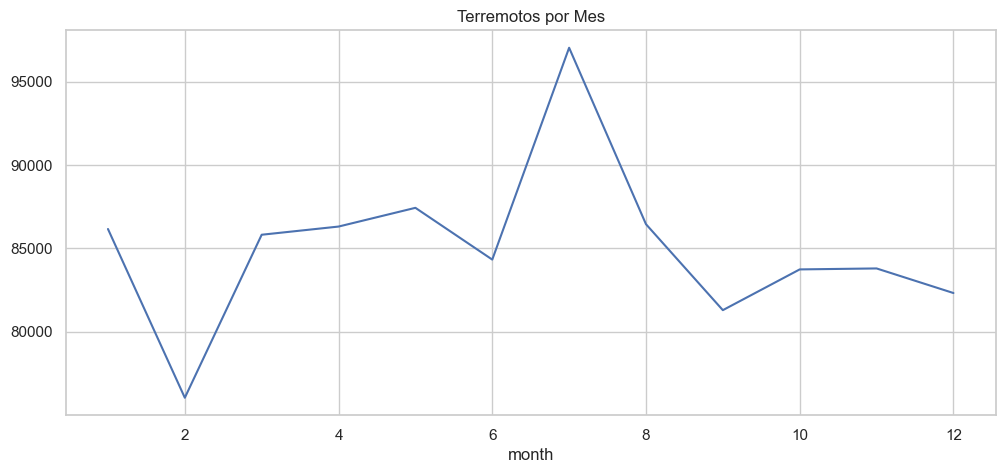

In [105]:
# Terremotos por Mes.

earthquakes_per_month = df.groupby("month").size().sort_index()

earthquakes_per_month.plot(figsize=(12,5))
plt.title('Terremotos por Mes')
plt.show()

## 6.- Analisis Geografico.

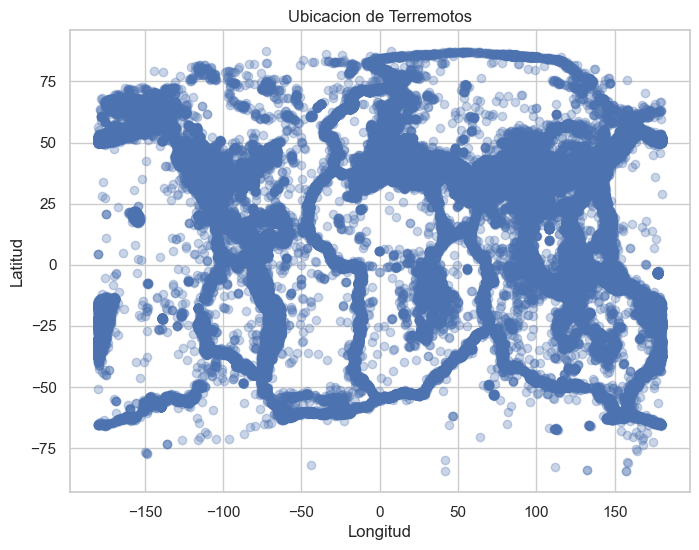

In [81]:
# Grafica con la Ubicacion de los Terremotos.

plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'], alpha = 0.3)
plt.title('Ubicacion de Terremotos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

## 7.- Correlaciones.

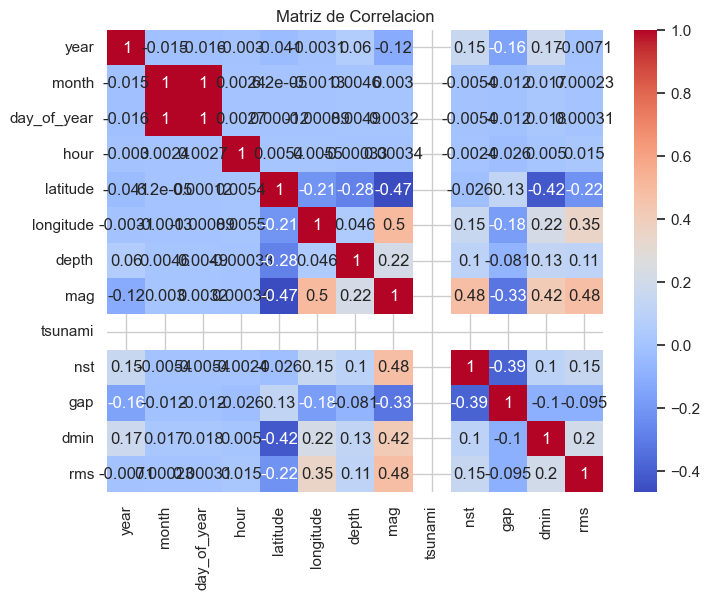

In [83]:
# Mapa de Calor de la Matriz de Correlacion.

plt.figure(figsize = (8,6))
#sns.heatmap(df.corr(numeric_only = True), annot=True, cmap = "YlGnBu")
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap = "coolwarm")
plt.title('Matriz de Correlacion')
plt.show()

## Insights iniciales.

- La mayoría de terremotos tienen magnitud entre X y Y
- Existen outliers importantes
- Se observa un incremento/disminución en ciertos años
- Hay correlación entre magnitud y profundidad (o no)

In [85]:
df.isnull().sum()

id                     0
time                   0
year                   0
month                  0
day_of_year            0
hour                   0
latitude               0
longitude              0
depth                892
mag                    0
magType               84
place                  0
type                   0
tsunami                0
mag_category           0
depth_category       898
nst               495715
gap               381048
dmin              673708
rms               176552
net                    0
updated                0
status                 0
dtype: int64

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054683 entries, 0 to 1054682
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1054683 non-null  str    
 1   time            1054683 non-null  str    
 2   year            1054683 non-null  int64  
 3   month           1054683 non-null  int64  
 4   day_of_year     1054683 non-null  int64  
 5   hour            1054683 non-null  int64  
 6   latitude        1054683 non-null  float64
 7   longitude       1054683 non-null  float64
 8   depth           1053791 non-null  float64
 9   mag             1054683 non-null  float64
 10  magType         1054599 non-null  str    
 11  place           1054683 non-null  str    
 12  type            1054683 non-null  str    
 13  tsunami         1054683 non-null  int64  
 14  mag_category    1054683 non-null  str    
 15  depth_category  1053785 non-null  str    
 16  nst             558968 non-null   float64
 17  

## 8.- Outliers (Clave).

In [88]:
# Magnitud (escala Richter normalmente 0–10)

df['mag'].describe()

count    1.054683e+06
mean     3.844124e+00
std      9.303126e-01
min      7.000000e-01
25%      2.940000e+00
50%      4.000000e+00
75%      4.500000e+00
max      9.500000e+00
Name: mag, dtype: float64

In [92]:
# Filtrar Valores Irreales.

df = df[(df['mag'] > 0) & (df['mag'] <= 10)]

In [93]:
# Profundidad (Depth).

df['depth'].describe()

count    1.053791e+06
mean     5.329371e+01
std      9.954571e+01
min     -4.000000e+00
25%      1.000000e+01
50%      1.978000e+01
75%      4.580000e+01
max      7.358000e+02
Name: depth, dtype: float64

In [94]:
df = df[df['depth'] > 0]

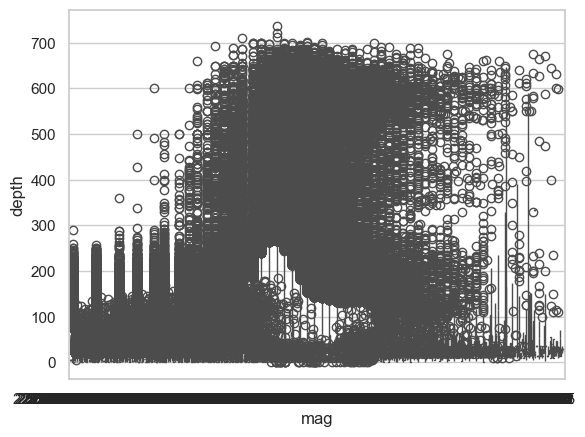

In [99]:
# Visualizacion de Outliers

sns.boxplot(x = df['mag'], y = df['depth'])
plt.show()

## 9.- Validar Coordenadas

In [96]:
# Validacion de coordenadas

df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]

## 10.- Consistencia Temporal.

In [98]:
df = df[(df['year'] >= 1900) & (df['year'] <= 2025)]

## 11.- Relacion Magnitud Vs. Profundidad.

#### No siempre hay correlacion fuerte necesariamente entre los eventos profundos y los eventos mas fuertes.

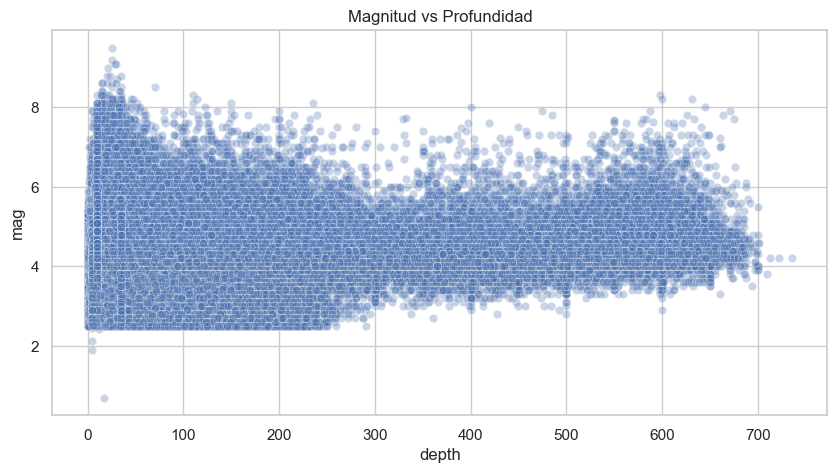

In [101]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df["depth"], y=df["mag"], alpha=0.3)
plt.title("Magnitud vs Profundidad")
plt.show()

## 12.- Top de Paises o Regiones con Mayor Actividad Sismica

In [120]:
region = df['place'].value_counts()
region.head(15)

place
south of the Fiji Islands                9697
South Sandwich Islands region            8837
Fiji region                              6970
Kermadec Islands region                  6633
Rat Islands, Aleutian Islands, Alaska    5619
Izu Islands, Japan region                4497
south of the Kermadec Islands            4448
Bonin Islands, Japan region              4048
Kermadec Islands, New Zealand            3788
Kuril Islands                            3454
northern Mid-Atlantic Ridge              3378
5 km SW of Volcano, Hawaii               2829
6 km SW of Volcano, Hawaii               2536
Mid-Indian Ridge                         2517
Mariana Islands region                   2452
Name: count, dtype: int64

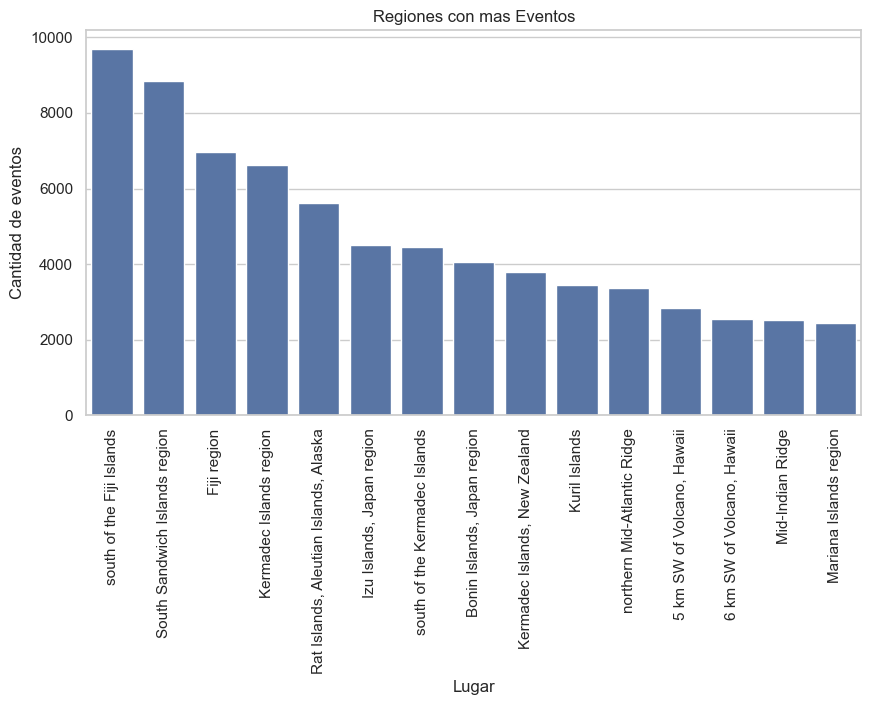

In [119]:
# Grafica de Regiones con mas Terremotos.

plt.figure(figsize=(10,5))
sns.barplot(region.head(15))
plt.xlabel('Lugar')
plt.ylabel('Cantidad de eventos')
plt.title('Regiones con mas Eventos')
plt.xticks(rotation = 90)
#plt.tight_layout()
plt.show()

## 13.- Matriz de Correlacion de Magnitud Vs Profundidad.

#### Los valores cercanos a 0 tienen poca relacion lo que ayuda a explicar el comportamiento.

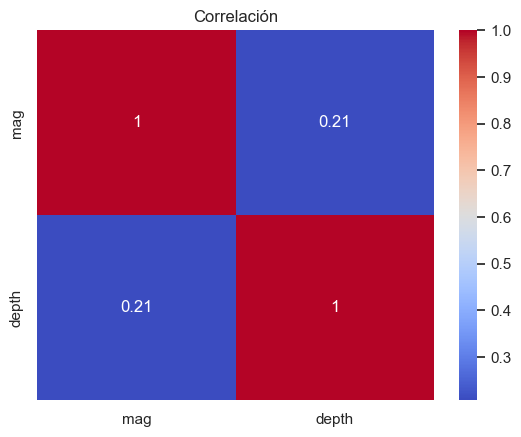

In [110]:
corr = df[["mag", "depth"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación")
plt.show()